In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import json
from pathlib import Path
import pandas as pd

allMatchesEventsJson = []

count = 0

for file in Path('data/events').glob('*.json'):
    if count > 100:
        break
    count += 1
    with open(file, 'r') as match:
        events = json.load(match)
        match_id = file.stem
        for item in events:
            item['match_id'] = int(match_id)
            allMatchesEventsJson.append(item)

events_df = pd.DataFrame(allMatchesEventsJson)

In [3]:
non_playing_events_ids = [5, 18, 19, 26, 27, 29, 34, 35, 36, 40]

In [4]:
# rename carry to carry_to
events_df = events_df.rename(columns={'carry': 'carry_to'})

In [5]:
set_to_id = lambda x: x.apply(lambda d: int(d['id']) if isinstance(d, dict) and 'id' in d else d)
id_cols = ['type', 'possession_team', 'play_pattern', 'team', 'player', 'position']
events_df[id_cols] = events_df[id_cols].apply(set_to_id)

In [ ]:
from tools_df import *
cols_to_expand = events_df.columns[18:]
for col in cols_to_expand:
    events_df = expand_column_pd(events_df, col)

In [7]:
events_df = events_df.apply(set_to_id)

In [8]:
playing_events_df = events_df[~events_df['type'].isin(non_playing_events_ids)]

In [9]:
playing_events_df.drop(columns=['tactics'], inplace=True)

In [10]:
nAn = playing_events_df['block_deflection'].unique()[0]

In [11]:
playing_events_df.info()

<class 'pandas.DataFrame'>
Index: 346147 entries, 4 to 348801
Columns: 107 entries, id to injury_stoppage_in_chain
dtypes: float64(33), int64(10), object(60), str(4)
memory usage: 285.2+ MB


In [12]:
# print list of columns zero-indexed
for i, col in enumerate(playing_events_df.columns):
    print(f"{i}: {col}")

0: id
1: index
2: period
3: timestamp
4: minute
5: second
6: type
7: possession
8: possession_team
9: play_pattern
10: team
11: duration
12: match_id
13: related_events
14: player
15: position
16: location
17: pass_recipient
18: pass_length
19: pass_angle
20: pass_height
21: pass_end_location
22: pass_body_part
23: pass_type
24: pass_outcome
25: pass_switch
26: pass_aerial_won
27: pass_through_ball
28: pass_technique
29: pass_cross
30: pass_inswinging
31: pass_assisted_shot_id
32: pass_shot_assist
33: pass_outswinging
34: pass_cut_back
35: pass_straight
36: pass_miscommunication
37: pass_no_touch
38: pass_deflected
39: pass_goal_assist
40: pass_backheel
41: carry_to_end_location
42: ball_receipt_outcome
43: counterpress_0
44: under_pressure_0
45: off_camera_0
46: duel_type
47: duel_outcome
48: foul_committed_offensive
49: foul_committed_type
50: foul_committed_card
51: foul_committed_advantage
52: foul_committed_penalty
53: interception_outcome
54: dribble_outcome
55: dribble_overrun
5

In [13]:
for column in playing_events_df.columns[17:]:
    col = playing_events_df[column]
    non_null = col.dropna()

    if len(non_null) > 0 and non_null.map(lambda x: isinstance(x, bool)).all():
        print(column)
        playing_events_df[column] = col.fillna(False)

pass_switch
pass_aerial_won
pass_through_ball
pass_cross
pass_inswinging
pass_shot_assist
pass_outswinging
pass_cut_back
pass_straight
pass_miscommunication
pass_no_touch
pass_deflected
pass_goal_assist
pass_backheel
counterpress_0
under_pressure_0
off_camera_0
foul_committed_offensive
foul_committed_advantage
foul_committed_penalty
dribble_overrun
dribble_nutmeg
dribble_no_touch
clearance_right_foot
clearance_head
clearance_left_foot
clearance_aerial_won
clearance_other
out_0
miscontrol_aerial_won
shot_first_time
shot_aerial_won
shot_one_on_one
shot_deflected
shot_open_goal
shot_follows_dribble
shot_saved_off_target
shot_saved_to_post
shot_redirect
goalkeeper_punched_out
goalkeeper_shot_saved_to_post
goalkeeper_shot_saved_off_target
goalkeeper_lost_in_play
goalkeeper_success_in_play
foul_won_defensive
foul_won_advantage
foul_won_penalty
ball_recovery_recovery_failure
ball_recovery_offensive
block_save_block
block_deflection
block_offensive


In [14]:
from tools_file import *
# load json files 
event_types_dict = json_file_to_dict('info/event_type.json')
positions_dict = json_file_to_dict('info/position.json')
positions_abbrev_dict = json_file_to_dict('info/position.json', value_field='abbrev')
play_patterns_dict = json_file_to_dict('info/play_pattern.json')

In [15]:
end_loc_cols = [s for s in playing_events_df.columns if "end_location" in s]
outcome_cols = [s for s in playing_events_df.columns if "outcome" in s]
type_cols = [s for s in playing_events_df.columns if "_type" in s]
technique_cols = [s for s in playing_events_df.columns if "technique" in s]
body_part_cols = [s for s in playing_events_df.columns if "body_part" in s]
aerial_won_cols = [s for s in playing_events_df.columns if "aerial_won" in s]

playing_events_df['end_location'] = playing_events_df[end_loc_cols].bfill(axis=1).iloc[:, 0]
playing_events_df['outcome'] = playing_events_df[outcome_cols].bfill(axis=1).iloc[:, 0]
playing_events_df['action_type'] = playing_events_df[type_cols].bfill(axis=1).iloc[:, 0]
playing_events_df['technique'] = playing_events_df[technique_cols].bfill(axis=1).iloc[:, 0]
playing_events_df['body_part'] = playing_events_df[body_part_cols].bfill(axis=1).iloc[:, 0]
playing_events_df['aerial_won'] = playing_events_df[aerial_won_cols].bfill(axis=1).iloc[:, 0]

playing_events_df.drop(columns=end_loc_cols + outcome_cols + type_cols +
                       technique_cols + body_part_cols + aerial_won_cols, inplace=True)

In [16]:
playing_events_df.dropna(axis=1, how='all', inplace=True)

In [17]:
playing_events_df['foul_committed_card'] = playing_events_df['foul_committed_card'].apply(lambda x: 72-x)
playing_events_df['bad_behaviour_card'] = playing_events_df['bad_behaviour_card'].apply(lambda x: 72-x)

In [18]:
# collapse body part cols
clearance_cols = [s for s in playing_events_df.columns if "clearance_" in s]

playing_events_df.drop(columns=clearance_cols, inplace=True)

In [19]:
import numpy as np

def split_location(df, col):
    df[f'{col}_x'] = df[col].apply(lambda v: v[0] if isinstance(v, list) else np.nan)
    df[f'{col}_y'] = df[col].apply(lambda v: v[1] if isinstance(v, list) else np.nan)
    return df

playing_events_df = split_location(playing_events_df, 'location')
playing_events_df = split_location(playing_events_df, 'end_location')
playing_events_df.drop(columns=['location', 'end_location'], inplace=True)

In [20]:
# get time col and take exact millisecond of event
playing_events_df['millisecond'] = playing_events_df['timestamp'].apply(lambda x: int(x.split('.')[1]) if '.' in x else 0)

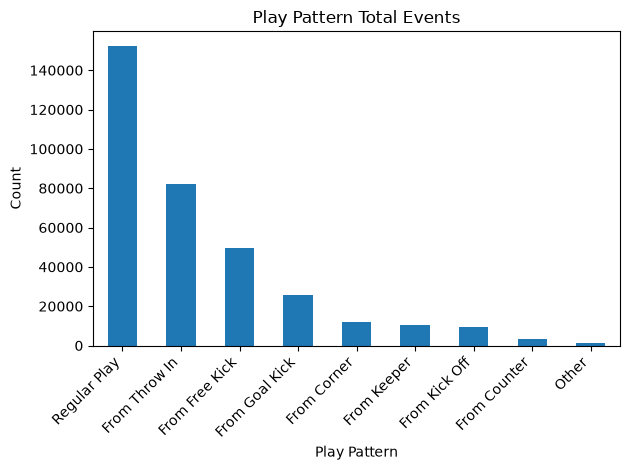

In [21]:
# play patterns type bar chart
import matplotlib.pyplot as plt

counts = playing_events_df['play_pattern'].value_counts()
counts.index = counts.index.map(play_patterns_dict)

counts.plot(kind='bar', title='Play Pattern Total Events')
plt.xlabel('Play Pattern')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Text(0, 0.5, 'Count')

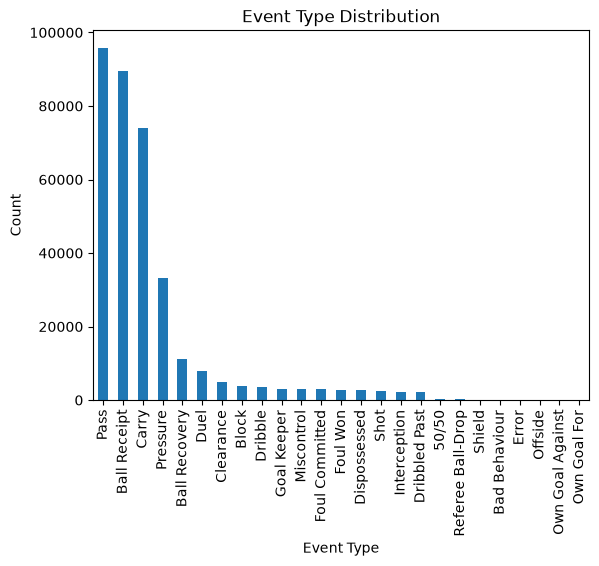

In [22]:
import matplotlib.pyplot as plt
# plot event type distribution
type_df = playing_events_df['type']
type_df['name'] = type_df.map(event_types_dict)
type_df['name'].value_counts().plot(kind='bar', stacked=True)
plt.title("Event Type Distribution")
plt.xlabel("Event Type")
plt.ylabel("Count")

In [38]:
print(event_types_dict)
print(positions_dict)

{2: 'Ball Recovery', 3: 'Dispossessed', 4: 'Duel', 5: 'Camera On', 6: 'Block', 8: 'Offside', 9: 'Clearance', 10: 'Interception', 14: 'Dribble', 16: 'Shot', 17: 'Pressure', 18: 'Half Start', 19: 'Substitution', 20: 'Own Goal Against', 21: 'Foul Won', 22: 'Foul Committed', 23: 'Goal Keeper', 24: 'Bad Behaviour', 25: 'Own Goal For', 26: 'Player On', 27: 'Player Off', 28: 'Shield', 30: 'Pass', 33: '50/50', 34: 'Half End', 35: 'Starting XI', 36: 'Tactical Shift', 37: 'Error', 38: 'Miscontrol', 39: 'Dribbled Past', 40: 'Injury Stoppage', 41: 'Referee Ball-Drop', 42: 'Ball Receipt', 43: 'Carry'}
{1: 'Goalkeeper', 2: 'Right Back', 3: 'Right Center Back', 4: 'Center Back', 5: 'Left Center Back', 6: 'Left Back', 7: 'Right Wing Back', 8: 'Left Wing Back', 9: 'Right Defensive Midfield', 10: 'Center Defensive Midfield', 11: 'Left Defensive Midfield', 12: 'Right Midfield', 13: 'Right Center Midfield', 14: 'Center Midfield', 15: 'Left Center Midfield', 16: 'Left Midfield', 17: 'Right Wing', 18: 'Righ

In [39]:
id_cols = ['id', 'match_id', 'index']  # not features
categorical_cols = ['type', 'play_pattern', 'position', 'team', 'player', 'pass_recipient', 'pass_assisted_shot_id', 'foul_committed_card',
                    'shot_key_pass_id', 'goalkeeper_position', 'bad_behaviour_card', 'outcome', 'action_type',
                    'technique', 'body_part']
numeric_cols = ['timestamp','minute', 'second', 'millisecond', 'duration', 'location_x', 'location_y', 'end_location_x', 'end_location_y', 'period',
                'pass_length', 'pass_angle', 'pass_height']
boolean_cols = [c for c in playing_events_df.columns if playing_events_df[c].dropna().map(lambda v: isinstance(v, bool)).all()]
list_cols = ['related_events', 'shot_freeze_frame']  # variable-length, e.g. freeze frames, tactics lineup

In [40]:
from mplsoccer import Pitch

def get_possession_chains(match_id, df):
    match_df = df[df['match_id'] == match_id]
    match_df = match_df.sort_values(by=['timestamp'])

    possession_ids = np.sort(match_df['possession'].unique())
    possession_chains_dict = {}
    possession_count = possession_ids.shape[0]

    possession_chains_dict = {possession_id: match_df[match_df['possession'] == possession_id] for possession_id in possession_ids}

    print(f"Match ID: {match_id} | Possession Count: {possession_count}")
    return possession_ids, possession_chains_dict

def visualise_possession_chain(possession_id, possession_chains_dict, colour='yellow'):
    possession_df = possession_chains_dict[possession_id]
    pitch = Pitch(pitch_type='statsbomb', pitch_color='#2e5e3e', line_color='white')
    fig, ax = pitch.draw(figsize=(10, 6))
    for i in range(len(possession_df) - 1):
        event = possession_df.iloc[i]
        next_event = possession_df.iloc[i + 1]
        if pd.notnull(event['location_x']) and pd.notnull(event['location_y']) and pd.notnull(next_event['location_x']) and pd.notnull(next_event['location_y']):
            pitch.arrows(event['location_x'], event['location_y'], next_event['location_x'], next_event['location_y'], width=1.5, headwidth=4, headlength=4, color=colour, ax=ax)
            
            # alternative way to draw arrows using annotate
            #ax.annotate('', xy=(next_event['location_x'], next_event['location_y']), xytext=(event['location_x'], event['location_y']), arrowprops=dict(arrowstyle='->', color=colour, alpha=0.7, lw=2))

    plt.title(f"Possession ID: {possession_id}")
    plt.show()

In [41]:
playing_events_df['match_id'].unique()

array([3879600, 3901250, 3754300, 3912186, 2275050,   19795, 3825894,
          7298, 3928994, 3753996, 3900504, 3911315, 3753979,  265958,
       3890360, 3881571, 3879745, 3754245, 3912539,   69182, 3912493,
       3902240, 3890419,   18242,   69301, 3901196, 3912240, 3775631,
       3825601,  303696, 3754183,   69244, 3825744, 3901179, 3754029,
       3911529, 3938644, 3788742, 3913144, 3911483, 3890272, 3773474,
       3910945, 3829419, 3825590, 3837954, 3901207, 3879657, 3879712,
       3754212, 2275142, 3881526, 3878553, 3890337,  266620, 3900553,
       3893798, 3825656, 3879591, 3754091, 3912217,    7559, 3813271,
       3913113, 3929002, 3825713, 3920389,   69213, 3754341, 3901211,
       3879641, 3825586, 3912597, 3910953, 3911641, 3890264, 3900545,
       3890321, 3878545, 3881530, 3869354, 3825569, 3920409, 3775559,
       2275154, 3754204, 3879704, 3888711, 3813288, 3890458,   69340,
       3912201, 3754087, 3879587, 3825640,   69205, 3754068, 3879568,
       3922658, 3825

In [42]:
test_match_id = 19804
test_team_1_id = playing_events_df[playing_events_df['match_id'] == test_match_id]['team'].unique()[0]
test_team_2_id = playing_events_df[playing_events_df['match_id'] == test_match_id]['team'].unique()[1]

print(f"Test Match ID: {test_match_id} | Team 1 ID: {test_team_1_id} | Team 2 ID: {test_team_2_id}")

Test Match ID: 19804 | Team 1 ID: 969 | Team 2 ID: 968


Match ID: 19804 | Possession Count: 214


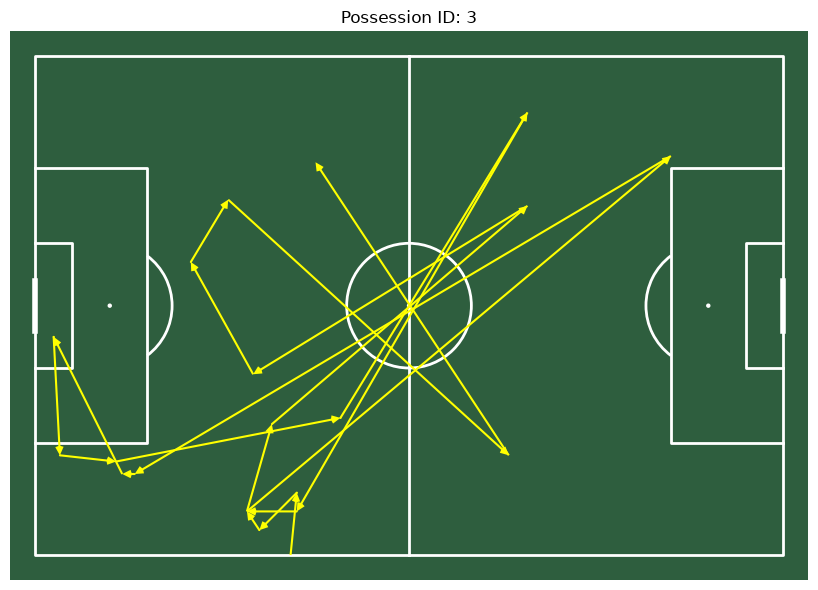

In [43]:
poss_ids, poss_chains = get_possession_chains(test_match_id, playing_events_df)
visualise_possession_chain(poss_ids[1], poss_chains)

In [44]:
# get players, and positions for match
def get_lineups_and_subs(match_id, df):
    match_lineups = df[(df['type'] == 35) & (df['match_id'] == match_id)]
    match_subs = df[(df['type'] == 26) & (df['match_id'] == match_id)]

    teams = match_lineups['team'].unique()

    lineup_dict = {}
    for team in teams:
        lineup_dict[int(team)] = match_lineups[match_lineups['team'] == team]['tactics'].iloc[0]

    subs_dict = {}
    for team in teams:
        subs_dict[int(team)] = []
        for sub in match_subs[match_subs['team'] == team].iloc:
            subs_dict[int(team)].append((sub['player'], sub['position']))

    return lineup_dict, subs_dict


In [55]:
def get_player_average_position_in_match(player_id, match_id, df):
    player_df = df[(df['player'] == player_id) & (df['match_id'] == match_id)]
    avg_x = np.mean(player_df['location_x'])
    avg_y = np.mean(player_df['location_y'])
    return avg_x, avg_y

def get_player_average_position_in_possession(player_id, match_id, df):
    # average position of player when passing or receiving a pass in the match
    print(f"Getting average position for player {player_id} in match {match_id}")
    match_df = df[(df['match_id'] == match_id)]
    player_df = match_df[((match_df['player'] == player_id) | (match_df['pass_recipient'] == player_id)) 
                         & (match_df['type'] == 30)]  # type 30 = pass
    avg_x = np.mean(player_df['location_x'])
    avg_y = np.mean(player_df['location_y'])
    return avg_x, avg_y

def get_pass_network(match_id, team_id, df):
    match_df = df[(df['match_id'] == match_id) & (df['team'] == team_id)]
    pass_df = match_df[match_df['type'] == 30]  # type 30 = passs
    pass_network = {}
    
    for player in match_df['player'].unique():
        if pd.isnull(player):
            continue
        pass_network_for_player = {}
        player_passes = pass_df[pass_df['player'] == player]

        for pass_played in player_passes.iloc:
            recipient = pass_played['pass_recipient']
            if pd.notnull(recipient):
                try:
                    pass_network_for_player[int(recipient)] += 1
                except KeyError:
                    pass_network_for_player[int(recipient)] = 1
        pass_network[int(player)] = pass_network_for_player
    
    return pass_network

def plot_pass_network(match_id, df, team_id, lineup, colour='white'):
    pass_network = get_pass_network(match_id, team_id, df)
    pitch = Pitch(pitch_type='statsbomb', pitch_color='#2e5e3e', line_color='white')
    fig, ax = pitch.draw(figsize=(10, 6))

    print(lineup)

    lineup_ids = [player['player']['id'] for player in lineup]
    lineup_names = {player['player']['id']: player['player']['name'] for player in lineup}
    lineup_positions = {player['player']['id']: player['position']['id'] for player in lineup}

    avg_pos = {player_id: get_player_average_position_in_possession(player_id, match_id, df) for player_id in lineup_ids}
    
    for passer in lineup_ids:
        passer_avg_x, passer_avg_y = avg_pos[passer]

        circle = plt.Circle((passer_avg_x, passer_avg_y), radius=2, color='#FF4444',
                         edgecolor='white', linewidth=3, zorder=5)
        ax.add_patch(circle)
        ax.text(passer_avg_x, passer_avg_y, positions_abbrev_dict[lineup_positions[passer]], color='white', 
                fontsize=8, ha='center', va='center', zorder=6)

        for recipient in lineup_ids:
            recipient_avg_x, recipient_avg_y = avg_pos[recipient]
            count = pass_network[passer].get(recipient)

            if count is not None:
                pitch.arrows(passer_avg_x, passer_avg_y, recipient_avg_x, recipient_avg_y,
                            width=count/2.5, headwidth=0.25*count, headlength=0.25*count,
                            color=colour, ax=ax)
    
    plt.title(f"Pass Network for Match ID, Team ID: {match_id}, {team_id}")
    plt.show()

In [56]:
pn = get_pass_network(3879600, 1683, playing_events_df)

[{'player': {'id': 22032, 'name': 'Hannah Hampton'}, 'position': {'id': 1, 'name': 'Goalkeeper'}, 'jersey_number': 29}, {'player': {'id': 19592, 'name': 'Harriet Scott'}, 'position': {'id': 2, 'name': 'Right Back'}, 'jersey_number': 23}, {'player': {'id': 19502, 'name': 'Meaghan Sargeant'}, 'position': {'id': 3, 'name': 'Right Center Back'}, 'jersey_number': 3}, {'player': {'id': 19503, 'name': 'Aoife Mannion'}, 'position': {'id': 5, 'name': 'Left Center Back'}, 'jersey_number': 25}, {'player': {'id': 15569, 'name': 'Kerys Harrop'}, 'position': {'id': 6, 'name': 'Left Back'}, 'jersey_number': 6}, {'player': {'id': 19501, 'name': 'Hayley Ladd'}, 'position': {'id': 9, 'name': 'Right Defensive Midfield'}, 'jersey_number': 4}, {'player': {'id': 10193, 'name': 'Chloe Arthur'}, 'position': {'id': 11, 'name': 'Left Defensive Midfield'}, 'jersey_number': 7}, {'player': {'id': 15563, 'name': 'Charlie Wellings'}, 'position': {'id': 17, 'name': 'Right Wing'}, 'jersey_number': 15}, {'player': {'id

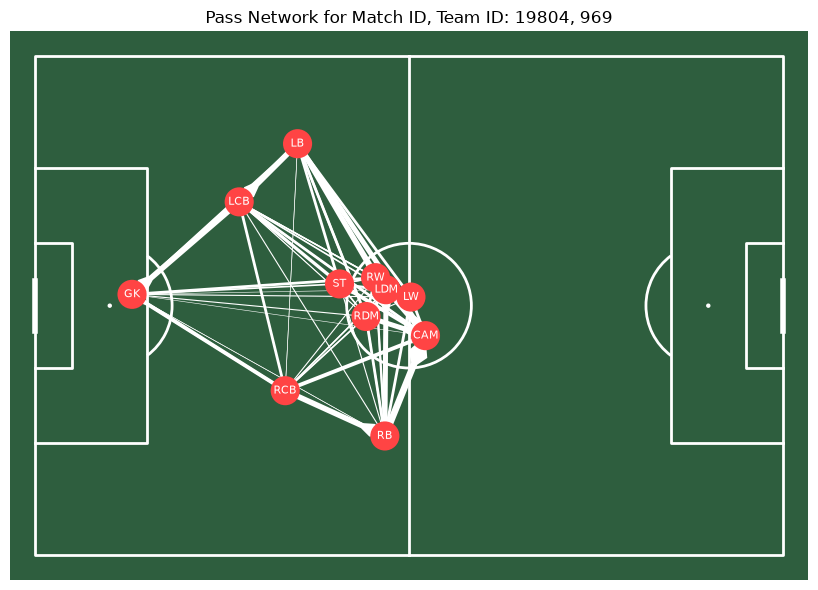

In [57]:
lineups, subs = get_lineups_and_subs(test_match_id, events_df)
plot_pass_network(test_match_id, playing_events_df, test_team_1_id, lineups[test_team_1_id]['lineup'])

In [58]:
# types of pass networks and positions to determine winners of matches
# types of in-possession / oop shapes to determine winners of matches